In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)


In [4]:
# Load dataset
df = pd.read_csv("Diabetes_Final_Data_V2.csv")

# Encode categorical columns
df['diabetic'] = df['diabetic'].map({'No': 0, 'Yes': 1})
df['gender'] = LabelEncoder().fit_transform(df['gender'])

# Split features/target
X = df.drop('diabetic', axis=1)
y = df['diabetic']

In [5]:
from imblearn.over_sampling import SMOTE

# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE only to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]
}

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train_resampled)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:,1]


In [7]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train_resampled)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:,1]


In [8]:
import xgboost as xgb

scale_pos_weight = y_train_resampled.value_counts()[0] / y_train_resampled.value_counts()[1]

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                            scale_pos_weight=scale_pos_weight)
grid_xgb = GridSearchCV(xgb_clf, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_resampled)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:,1]


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [14:11:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = nn.fit(X_train_scaled, y_train_resampled, epochs=25, batch_size=32, verbose=0)

y_prob_nn = nn.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step


In [10]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = {
    'Logistic Regression': evaluate_model(y_test, y_pred_lr, y_prob_lr),
    'Random Forest': evaluate_model(y_test, y_pred_rf, y_prob_rf),
    'XGBoost': evaluate_model(y_test, y_pred_xgb, y_prob_xgb),
    'Neural Network': evaluate_model(y_test, y_pred_nn, y_prob_nn)
}

results_df = pd.DataFrame(results).T
print(results_df)


                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.791360   0.188976  0.695652  0.297214  0.810613
Random Forest        0.907169   0.333333  0.463768  0.387879  0.850159
XGBoost              0.913603   0.345679  0.405797  0.373333  0.840082
Neural Network       0.831801   0.200000  0.550725  0.293436  0.780404


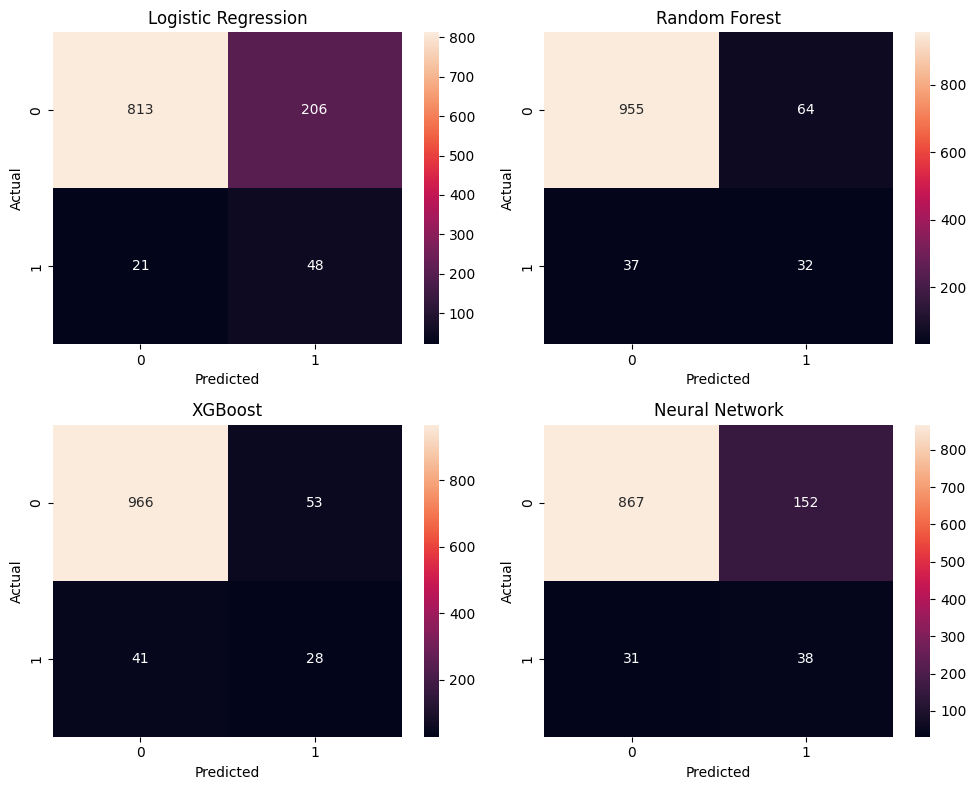

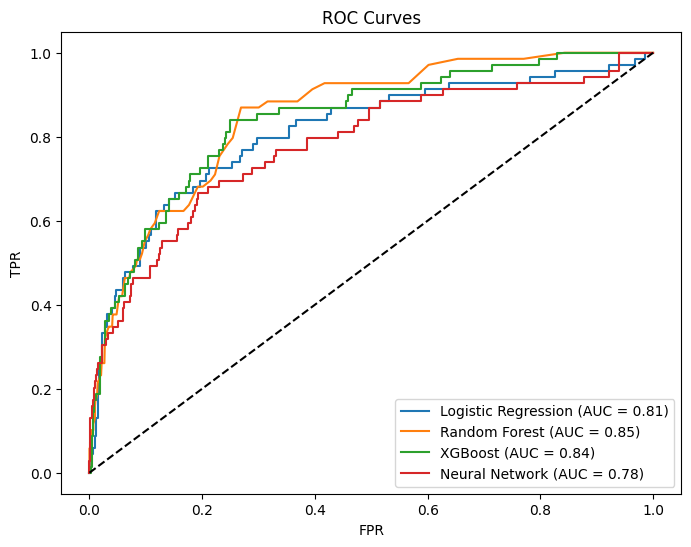

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'Neural Network': (y_pred_nn, y_prob_nn)
}

# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, (name, (ypred, _)) in enumerate(models.items()):
    sns.heatmap(confusion_matrix(y_test, ypred), annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8,6))
for name, (ypred, yprob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curves"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.show()


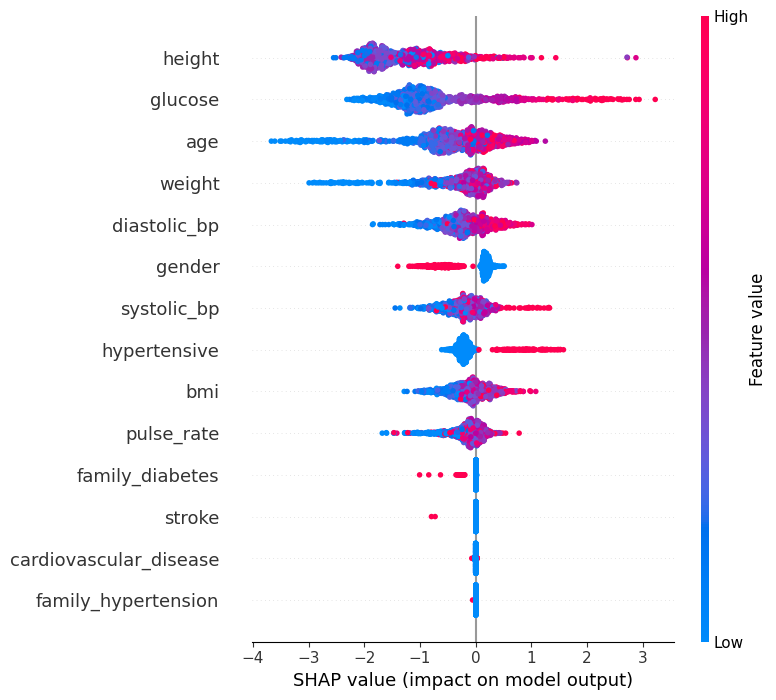

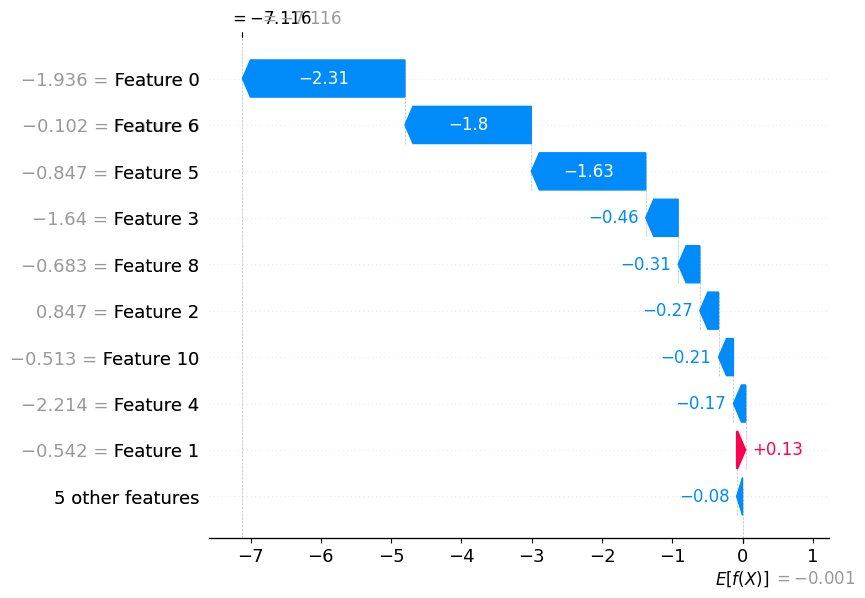

In [12]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, features=X_test_scaled, feature_names=X.columns)

# Optional: individual prediction
shap.plots.waterfall(shap_values[0])


In [13]:
!pip install imbalanced-learn xgboost shap


Defaulting to user installation because normal site-packages is not writeable
